# A numeric string does not contain a number

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/number-parser-locale/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/number-parser-locale/demo.ipynb)

`1.234` is **one point two three four** to a US reader and **one thousand two
hundred thirty four** to a German one. Both readings conform to their own
locale. Neither is a bug. Nothing in the string says which was meant.

A *reader* is four things multiplied together:

| | |
|---|---|
| **symbol table** | which character groups, which one is the decimal point |
| **grouping rule** | `1,234,567` vs `12,34,567` -- both are "commas every few digits" |
| **strictness** | does the reader check *where* the separators fall? |
| **scanner** | what happens on the characters the locale layer hands down |

Change any one of them and the same bytes become a different quantity, usually
with no error raised.

**What this notebook does**

1. Read the real CLDR symbol table for five locales, including the two separators that are not on a keyboard
2. Build the readers from scratch and run 35 strings through them
3. Count how often two readers return different numbers, and how far apart
4. Find the zero that was not in the file
5. Cross a border: write an amount in one locale, read it in another
6. Watch strict mode refuse a string its own locale just produced
7. Ask the only question that can actually decide a column
8. Try your own string

Every number below is computed in this notebook. Nothing is quoted from
elsewhere.

## Setup

Only `babel` (CLDR data), `pandas` and `matplotlib` are needed. `Decimal` and
`ctypes` are standard library.

In [1]:
from __future__ import annotations

import ctypes
import ctypes.util
import math
from dataclasses import dataclass
from decimal import ROUND_HALF_EVEN, Decimal, InvalidOperation
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import pandas as pd

try:
    import babel
    from babel.numbers import (NumberFormatError, format_decimal,
                               get_decimal_symbol, get_group_symbol,
                               parse_decimal)
except ImportError:
    !pip -q install babel
    import babel
    from babel.numbers import (NumberFormatError, format_decimal,
                               get_decimal_symbol, get_group_symbol,
                               parse_decimal)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
print("babel", babel.__version__)

babel 2.11.0


## 1. The symbol table, straight from CLDR

Before any parsing: what does each locale actually use? Two of these five are
characters no keyboard produces, which matters enormously later.

In [2]:
LOCALES = ["en_US", "de_DE", "fr_FR", "en_IN", "de_CH"]

rows = []
for loc in LOCALES:
    g, d = get_group_symbol(loc), get_decimal_symbol(loc)
    rows.append({
        "locale": loc,
        "group": repr(g),
        "group code point": " ".join("U+%04X" % ord(c) for c in g),
        "decimal": repr(d),
        "1234567.89 renders as": format_decimal(Decimal("1234567.89"), locale=loc),
    })
symbols = pd.DataFrame(rows)
symbols

,locale,group,group code point,decimal,1234567.89 renders as
0,en_US,"','",U+002C,'.',"1,234,567.89"
1,de_DE,'.',U+002E,"','","1.234.567,89"
2,fr_FR,'\u202f',U+202F,"','","1 234 567,89"
3,en_IN,"','",U+002C,'.',"12,34,567.89"
4,de_CH,'’',U+2019,'.',1’234’567.89


`fr_FR` groups with **U+202F NARROW NO-BREAK SPACE** and `de_CH` with
**U+2019 RIGHT SINGLE QUOTATION MARK**. An ASCII space, or an ASCII apostrophe,
is *not* the separator - so the string a human types is not the string the
locale defines. Section 4 measures what that costs.

## 2. Build the readers

Thirteen readers here: three scanners with no locale involved, and five locales
at two strictness settings each. The full project adds two more - real
JavaScript `Number()` and `parseFloat()` in a `node` subprocess - for 15 and
525 readings. Node is not guaranteed on Colab, so this notebook states those
two readers' behaviour as data instead of pretending to run them.

`c_strtod` is libc's own `strtod` through `ctypes` - not a Python imitation of
it. It is a **prefix** parser: it consumes what it can and stops, so it never
fails on trailing junk. That property produces the largest errors in this
notebook.

In [3]:
REJECTED, OK = "rejected", "ok"


@dataclass(frozen=True)
class Reading:
    reader: str
    status: str
    value: Optional[Decimal] = None
    note: str = ""

    @property
    def ok(self) -> bool:
        return self.status == OK

    @property
    def is_finite(self) -> bool:
        return self.ok and self.value is not None and self.value.is_finite()

    def display(self) -> str:
        if not self.ok:
            return "--"
        assert self.value is not None
        if not self.value.is_finite():
            return str(self.value)
        n = self.value.normalize()
        _, _, exp = n.as_tuple()
        return "{:e}".format(n) if isinstance(exp, int) and exp > 6 else format(n, "f")


def read_py_float(s: str) -> Reading:
    try:
        f = float(s)
    except (ValueError, TypeError):
        return Reading("py_float", REJECTED)
    if math.isinf(f):
        return Reading("py_float", OK, Decimal("Infinity") if f > 0 else Decimal("-Infinity"),
                       "overflowed to inf")
    if math.isnan(f):
        return Reading("py_float", OK, Decimal("NaN"))
    return Reading("py_float", OK, Decimal(repr(f)))


def read_py_decimal(s: str) -> Reading:
    try:
        return Reading("py_decimal", OK, Decimal(s))
    except (InvalidOperation, ValueError, TypeError):
        return Reading("py_decimal", REJECTED)


_libc = ctypes.CDLL(ctypes.util.find_library("c") or "libc.so.6")
_libc.strtod.restype = ctypes.c_double
_libc.strtod.argtypes = [ctypes.c_char_p, ctypes.POINTER(ctypes.c_char_p)]


def read_c_strtod(s: str) -> Reading:
    b = s.encode("utf-8")
    end = ctypes.c_char_p()
    val = _libc.strtod(b, ctypes.byref(end))
    consumed = len(b) - len(end.value if end.value is not None else b)
    if consumed == 0:
        # endptr == nptr and the return value is 0.0.  A caller who checks only
        # the return value reads this as a legitimate zero.
        return Reading("c_strtod", OK, Decimal(0), "consumed 0 bytes -> silent 0")
    note = "" if consumed == len(b) else "prefix only (%d/%d bytes)" % (consumed, len(b))
    if math.isinf(val):
        return Reading("c_strtod", OK, Decimal("Infinity") if val > 0 else Decimal("-Infinity"), note)
    if math.isnan(val):
        return Reading("c_strtod", OK, Decimal("NaN"), note)
    return Reading("c_strtod", OK, Decimal(repr(val)), note)


def read_locale(s: str, locale: str, strict: bool) -> Reading:
    name = "%s_%s" % (locale, "S" if strict else "L")
    try:
        return Reading(name, OK, parse_decimal(s, locale=locale, strict=strict))
    except (NumberFormatError, ValueError, TypeError, IndexError):
        return Reading(name, REJECTED)


READERS = ["py_float", "py_decimal", "c_strtod"] + \
    ["%s_%s" % (loc, k) for loc in LOCALES for k in ("S", "L")]


def read_all_readers(s: str) -> Dict[str, Reading]:
    out = {"py_float": read_py_float(s), "py_decimal": read_py_decimal(s),
           "c_strtod": read_c_strtod(s)}
    for loc in LOCALES:
        for strict in (True, False):
            r = read_locale(s, loc, strict)
            out[r.reader] = r
    return out


print("%d readers:" % len(READERS), ", ".join(READERS))

13 readers: py_float, py_decimal, c_strtod, en_US_S, en_US_L, de_DE_S, de_DE_L, fr_FR_S, fr_FR_L, en_IN_S, en_IN_L, de_CH_S, de_CH_L


### A note on the two JavaScript readers

The full project also runs `Number()` and `parseFloat()` in a real `node`
process, because JavaScript's rules are genuinely different: `Number("")` is
**0**, not an error, and `Number("0x1A")` is **26**. Node is not guaranteed on
Colab, so this notebook models the two facts that matter instead of pretending
to run them:

In [4]:
# From a real node v22 run (see numlocale.py for the live version):
JS_FACTS = pd.DataFrame([
    {"string": '""',        "Number(s)": "0",       "parseFloat(s)": "NaN"},
    {"string": '"   "',     "Number(s)": "0",       "parseFloat(s)": "NaN"},
    {"string": '"0x1A"',    "Number(s)": "26",      "parseFloat(s)": "0"},
    {"string": '"1,234"',   "Number(s)": "NaN",     "parseFloat(s)": "1"},
    {"string": '"1_000"',   "Number(s)": "NaN",     "parseFloat(s)": "1"},
    {"string": '"1234-"',   "Number(s)": "NaN",     "parseFloat(s)": "1234"},
    {"string": '"\u0661\u0662\u0663\u0664"', "Number(s)": "NaN", "parseFloat(s)": "NaN"},
])
JS_FACTS

,string,Number(s),parseFloat(s)
0,"""""",0,NaN
1,""" """,0,NaN
2,"""0x1A""",26,0
3,"""1,234""",NaN,1
4,"""1_000""",NaN,1
5,"""1234-""",NaN,1234
6,"""١٢٣٤""",NaN,NaN


Two things worth keeping: **an empty cell is 0 in JavaScript**, and JavaScript's
only failure channel is the *value* `NaN` - so `NaN < 1000` is `false` and a
range check on it passes in the wrong direction.

## 3. One corpus, every reader

Thirty-five strings a pipeline actually receives. Nothing here is exotic for
the sake of it - each one has a named source.

In [5]:
NNBSP, NBSP, RSQUO, MINUS = "\u202f", "\u00a0", "\u2019", "\u2212"

CORPUS: List[Tuple[str, str, str]] = [
    ("plain-int", "1234", "any system"),
    ("dot-3dp", "1.234", "US decimal OR German thousands"),
    ("comma-3dp", "1,234", "US thousands OR German decimal"),
    ("us-money", "1,234.56", "US/UK export"),
    ("de-money", "1.234,56", "German/Spanish export"),
    ("us-money-trailing0", "1,234.50", "US accounting, fixed 2dp"),
    ("de-money-trailing0", "1.234,50", "German accounting, fixed 2dp"),
    ("bare-money", "1234.50", "unformatted 2dp amount"),
    ("de-grouped", "1.234.567", "German grouped integer"),
    ("us-grouped", "1,234,567", "US grouped integer"),
    ("in-lakh", "12,34,567", "Indian lakh grouping"),
    ("fr-nnbsp", "1" + NNBSP + "234" + NNBSP + "567,89", "French, CLDR-correct"),
    ("fr-nbsp", "1" + NBSP + "234" + NBSP + "567,89", "French, NBSP - what tools emit"),
    ("fr-space", "1 234 567,89", "French, ASCII space - what humans type"),
    ("ch-rsquo", "1" + RSQUO + "234" + RSQUO + "567.89", "Swiss, CLDR-correct"),
    ("ch-apostrophe", "1'234'567.89", "Swiss, ASCII apostrophe"),
    ("de-comma-2dp", "1,23", "German 2dp decimal"),
    ("pep515", "1_000", "Python literal pasted into a CSV"),
    ("arabic-indic", "\u0661\u0662\u0663\u0664", "Arabic-Indic digits"),
    ("accounting-neg", "(1,234)", "accounting / Excel negative"),
    ("trailing-minus", "1234-", "SAP / COBOL trailing sign"),
    ("true-minus", MINUS + "1234", "copy-paste from a rendered page"),
    ("plain-neg", "-1,234.00", "US negative money"),
    ("currency-prefix", "$1,234.00", "currency glued to the amount"),
    ("percent-suffix", "12.5%", "percentage as text"),
    ("sci-notation", "1e3", "scientific notation"),
    ("sci-overflow", "1e309", "beyond IEEE-754 double range"),
    ("int53-plus1", "9007199254740993", "id beyond exact double range"),
    ("binary-inexact", "0.1", "not representable in binary"),
    ("hex", "0x1A", "hex literal in a text column"),
    ("empty", "", "empty cell"),
    ("blank", "   ", "whitespace-only cell"),
    ("trailing-junk", "12abc", "unit glued on / dirty cell"),
    ("nan-word", "NaN", "missing marker written as a word"),
    ("inf-word", "Infinity", "overflow marker"),
]


def escaped(raw: str) -> str:
    if not raw:
        return "(empty)"
    if not raw.strip():
        return "(%d spaces)" % len(raw)
    return "".join(c if 32 <= ord(c) <= 126 else "\\u%04x" % ord(c) for c in raw)


TABLE = {name: read_all_readers(raw) for name, raw, _ in CORPUS}
print("%d strings x %d readers = %d readings" % (
    len(CORPUS), len(READERS), len(CORPUS) * len(READERS)))

35 strings x 13 readers = 455 readings


In [6]:
grid = pd.DataFrame(
    [[TABLE[name][r].display() for r in READERS] for name, _, _ in CORPUS],
    index=[escaped(raw) for _, raw, _ in CORPUS], columns=READERS)
grid

,py_float,py_decimal,c_strtod,en_US_S,en_US_L,de_DE_S,de_DE_L,fr_FR_S,fr_FR_L,en_IN_S,en_IN_L,de_CH_S,de_CH_L
1234,1234,1234,1234,1234,1234,1234,1234,1234,1234,1234,1234,1234,1234
1.234,1.234,1.234,1.234,1.234,1.234,1234,1234,1.234,1.234,1.234,1.234,1.234,1.234
"1,234",--,--,1,1234,1234,1.234,1.234,1.234,1.234,1234,1234,--,--
"1,234.56",--,--,1,1234.56,1234.56,--,1.23456,--,--,1234.56,1234.56,--,--
"1.234,56",--,--,1.234,--,1.23456,1234.56,1234.56,--,--,--,1.23456,--,--
"1,234.50",--,--,1,--,1234.5,--,1.2345,--,--,--,1234.5,--,--
"1.234,50",--,--,1.234,--,1.2345,--,1234.5,--,--,--,1.2345,--,--
1234.50,1234.5,1234.5,1234.5,1234.5,1234.5,--,123450,1234.5,1234.5,1234.5,1234.5,1234.5,1234.5
1.234.567,--,--,1.234,--,--,1234567,1234567,--,--,--,--,--,--
"1,234,567",--,--,1,1234567,1234567,--,--,--,--,--,1234567,--,--


Read across any row. `1,234.56` -- an ordinary US invoice amount -- comes back as
`1234.56`, as `1.23456`, as `1`, and as a refusal, depending on who reads it.

## 4. How far apart do two conforming readings get?

For each string, take every finite reading and divide the largest by the
smallest. This is the factor by which a total can be wrong with nothing in the
logs.

In [7]:
def distinct_finite(name: str) -> List[Decimal]:
    seen: List[Decimal] = []
    for r in TABLE[name].values():
        if r.is_finite and not any(r.value == s for s in seen):
            seen.append(r.value)
    return sorted(seen)


def ratio_for(name: str) -> Optional[Decimal]:
    nz = [abs(d) for d in distinct_finite(name) if d != 0]
    return (max(nz) / min(nz)) if len(nz) >= 2 else None


spread = pd.DataFrame([{
    "string": escaped(raw),
    "provenance": prov,
    "readings": len(distinct_finite(name)),
    "factor apart": float(ratio_for(name)) if ratio_for(name) else None,
    "values": ", ".join(format(d.normalize(), "f") for d in distinct_finite(name))[:52],
} for name, raw, prov in CORPUS]).sort_values("factor apart", ascending=False)

multi = int((spread["readings"] >= 2).sum())
print("%d of %d strings have more than one reading" % (multi, len(CORPUS)))
# 18 here, 19 in the full project: the extra one is `0x1A`, where the two JS
# readers disagree with each other (Number -> 26, parseFloat -> 0) and this
# notebook has only one reader that accepts it.
assert multi == 18, multi
spread.head(18)

18 of 35 strings have more than one reading


,string,provenance,readings,factor apart,values
11,"1\u202f234\u202f567,89","French, CLDR-correct",2,1.234568e+06,"1, 1234567.89"
14,1\u2019234\u2019567.89,"Swiss, CLDR-correct",2,1.234568e+06,"1, 1234567.89"
9,"1,234,567",US grouped integer,2,1.234567e+06,"1, 1234567"
8,1.234.567,German grouped integer,2,1.000459e+06,"1.234, 1234567"
10,"12,34,567",Indian lakh grouping,2,1.028806e+05,"12, 1234567"
3,"1,234.56",US/UK export,3,1.234560e+03,"1, 1.23456, 1234.56"
5,"1,234.50","US accounting, fixed 2dp",3,1.234500e+03,"1, 1.2345, 1234.5"
22,"-1,234.00",US negative money,3,1.234000e+03,"-1234, -1.234, -1"
2,"1,234",US thousands OR German decimal,3,1.234000e+03,"1, 1.234, 1234"
4,"1.234,56",German/Spanish export,3,1.000454e+03,"1.234, 1.23456, 1234.56"


`1,234,567` is the extreme: **1,234,567x**. A locale reader returns
1234567; `parseFloat` stops at the first comma and returns **1**. Both are
documented behaviour.

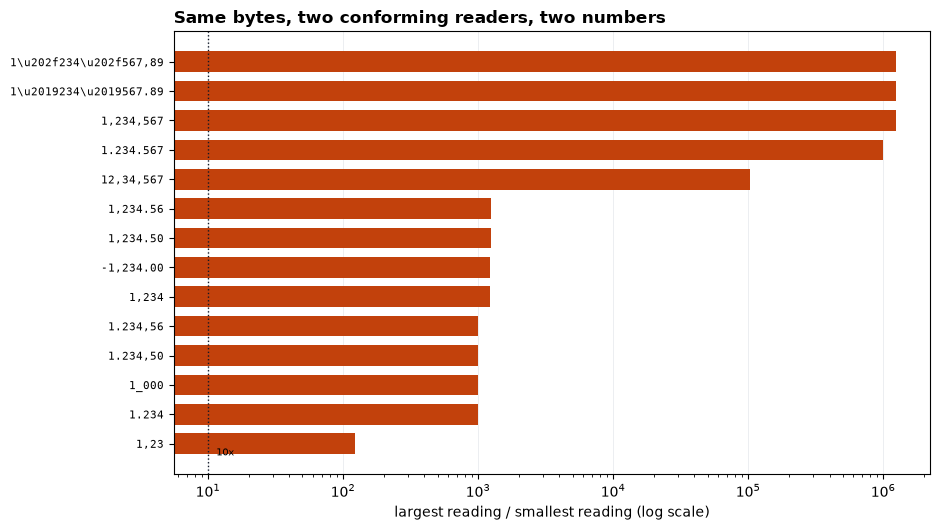

In [8]:
worst = spread.dropna(subset=["factor apart"]).head(14).iloc[::-1]
fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.barh(range(len(worst)), worst["factor apart"], color="#c2410c", height=0.7)
ax.set_yticks(range(len(worst)))
ax.set_yticklabels(worst["string"], fontsize=8, family="DejaVu Sans Mono")
ax.set_xscale("log")
ax.axvline(10, color="#111827", linestyle=":", linewidth=1)
ax.text(11.5, -0.4, "10x", fontsize=7)
ax.set_xlabel("largest reading / smallest reading (log scale)")
ax.set_title("Same bytes, two conforming readers, two numbers",
             loc="left", fontsize=12, fontweight="bold")
ax.grid(axis="x", color="#e5e7eb", linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("notebook_spread.png", dpi=150, facecolor="white")
plt.show()

## 5. Three strings that look identical on screen

The French separator is U+202F. Print all three and you cannot tell them apart;
only one of them is French.

In [9]:
look_alike = []
for name in ("fr-nnbsp", "fr-nbsp", "fr-space", "ch-rsquo", "ch-apostrophe"):
    raw = dict((n, r) for n, r, _ in CORPUS)[name]
    takers = [r for r in READERS if TABLE[name][r].ok]
    look_alike.append({
        "case": name,
        "as printed": raw,
        "as bytes": escaped(raw),
        "readers accepting": "%d / %d" % (len(takers), len(READERS)),
        "which": ", ".join(takers) or "nobody",
    })
pd.DataFrame(look_alike)

,case,as printed,as bytes,readers accepting,which
0,fr-nnbsp,"1 234 567,89","1\u202f234\u202f567,89",3 / 13,"c_strtod, fr_FR_S, fr_FR_L"
1,fr-nbsp,"1 234 567,89","1\u00a0234\u00a0567,89",1 / 13,c_strtod
2,fr-space,"1 234 567,89","1 234 567,89",1 / 13,c_strtod
3,ch-rsquo,1’234’567.89,1\u2019234\u2019567.89,3 / 13,"c_strtod, de_CH_S, de_CH_L"
4,ch-apostrophe,1'234'567.89,1'234'567.89,1 / 13,c_strtod


`fr-nbsp` and `fr-space` are accepted by **no locale reader at all** - only by
the prefix parser, which returns `1`. The correct French string is accepted by
`fr_FR` alone. So the wrong-looking string fails loudly and the
identical-looking one returns 1 with no complaint.

## 6. The zero that was not in the file

`strtod` returns `0.0` when it converts nothing, and signals that only through
`endptr`. A wrapper that returns just the double cannot tell the difference.

In [10]:
zeros = [{"string": escaped(raw), "provenance": prov,
          "strtod returns": TABLE[name]["c_strtod"].display(),
          "note": TABLE[name]["c_strtod"].note}
         for name, raw, prov in CORPUS
         if "silent 0" in TABLE[name]["c_strtod"].note]
print("%d of %d strings become a silent zero" % (len(zeros), len(CORPUS)))
assert len(zeros) == 6, len(zeros)
pd.DataFrame(zeros)

6 of 35 strings become a silent zero


,string,provenance,strtod returns,note
0,\u0661\u0662\u0663\u0664,Arabic-Indic digits,0,consumed 0 bytes -> silent 0
1,"(1,234)",accounting / Excel negative,0,consumed 0 bytes -> silent 0
2,\u22121234,copy-paste from a rendered page,0,consumed 0 bytes -> silent 0
3,"$1,234.00",currency glued to the amount,0,consumed 0 bytes -> silent 0
4,(empty),empty cell,0,consumed 0 bytes -> silent 0
5,(3 spaces),whitespace-only cell,0,consumed 0 bytes -> silent 0


A zero is the worst available failure value for an amount: it passes a not-null
check, passes a numeric type check, passes a range check, and moves an average.

Note what is in that list: `(1,234)` and `$1,234.00` - an accounting negative
and a currency-prefixed amount, both of which arrive daily.

## 7. Three ways to write a negative, none of them read as one

In [11]:
neg = []
for name in ("accounting-neg", "trailing-minus", "true-minus", "plain-neg"):
    raw = dict((n, r) for n, r, _ in CORPUS)[name]
    readings = {r: TABLE[name][r].display() for r in READERS if TABLE[name][r].ok}
    finite = [TABLE[name][r].value for r in READERS if TABLE[name][r].is_finite]
    neg.append({
        "string": raw,
        "means": "-1234",
        "accepted by": len(readings),
        "any negative reading?": "yes" if any(v < 0 for v in finite) else "NO",
        "readings": ", ".join(sorted(set(readings.values()))),
    })
pd.DataFrame(neg)

,string,means,accepted by,any negative reading?,readings
0,"(1,234)",-1234,1,NO,0
1,1234-,-1234,1,NO,1234
2,−1234,-1234,1,NO,0
3,"-1,234.00",-1234,6,yes,"-1, -1.234, -1234"


Only the ASCII hyphen survives. Accounting parentheses, a COBOL trailing sign
and U+2212 MINUS SIGN are all standard notations, and **not one reader in the
roster recovers the sign** - one comes back positive, two come back as zero.

## 8. Cross a border

An accounting system renders amounts with a fixed 2dp pattern. The file crosses
a border. Nothing in it records which locale wrote it, so the reader supplies
its own.

The `#,##0.00` pattern rounds `1.234` to `1.23` on the way out; that is the
writer's loss, so each reader is scored against the value **as rendered**.

In [12]:
PATTERN = "#,##0.00"
VALUES = [Decimal("1234567.89"), Decimal("1234.50"), Decimal("1000"),
          Decimal("0.50"), Decimal("1.234")]

cross = []
for v in VALUES:
    expected = v.quantize(Decimal("0.01"), rounding=ROUND_HALF_EVEN)
    for wrote in LOCALES:
        rendered = format_decimal(v, format=PATTERN, locale=wrote)
        for read in LOCALES:
            for strict in (True, False):
                r = read_locale(rendered, read, strict)
                if not r.ok:
                    status, got = "error", None
                else:
                    got = r.value
                    status = "ok" if got == expected else "wrong"
                cross.append({"value": str(v), "wrote": wrote, "read": read,
                              "strict": strict, "rendered": rendered,
                              "should be": str(expected),
                              "got": str(got) if got is not None else "",
                              "status": status})
cross = pd.DataFrame(cross)
counts = cross["status"].value_counts()
print("%d runs: %d ok, %d refused, %d SILENTLY WRONG" % (
    len(cross), counts.get("ok", 0), counts.get("error", 0), counts.get("wrong", 0)))
assert len(cross) == 250 and counts["wrong"] == 22
cross[cross.status == "wrong"][["wrote", "read", "strict", "rendered", "should be", "got"]]

250 runs: 97 ok, 131 refused, 22 SILENTLY WRONG


,wrote,read,strict,rendered,should be,got
53,en_US,de_DE,False,"1,234.50",1234.50,1.23450
61,de_DE,en_US,False,"1.234,50",1234.50,1.23450
67,de_DE,en_IN,False,"1.234,50",1234.50,1.23450
83,en_IN,de_DE,False,"1,234.50",1234.50,1.23450
103,en_US,de_DE,False,"1,000.00",1000.00,1.00000
111,de_DE,en_US,False,"1.000,00",1000.00,1.00000
117,de_DE,en_IN,False,"1.000,00",1000.00,1.00000
133,en_IN,de_DE,False,"1,000.00",1000.00,1.00000
153,en_US,de_DE,False,0.50,0.50,50
161,de_DE,en_US,False,"0,50",0.50,50


Every silently wrong run is a **loose** reader treating the other locale's
decimal point as a group separator. `0.50` becomes `50`. `1,234.50` becomes
`1.23450`. Money moves by two or three orders of magnitude and the row still
looks like money.

A refusal, by contrast, is the good outcome: loud and recoverable.

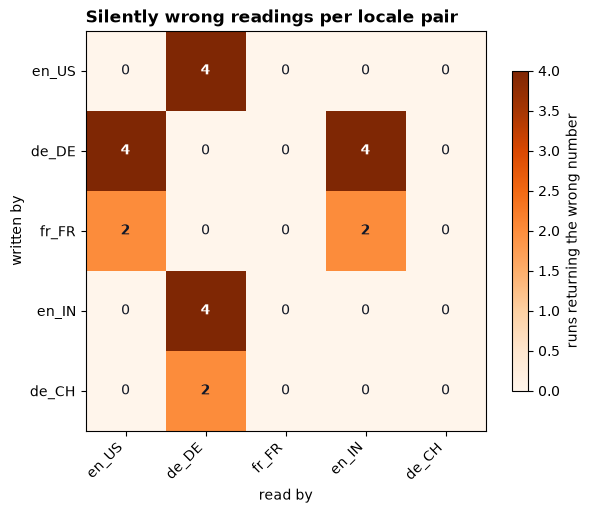

In [13]:
pivot = (cross.assign(w=(cross.status == "wrong").astype(int))
              .pivot_table(index="wrote", columns="read", values="w", aggfunc="sum")
              .reindex(index=LOCALES, columns=LOCALES))

fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(pivot.values, cmap="Oranges", vmin=0, vmax=pivot.values.max())
for i in range(len(LOCALES)):
    for j in range(len(LOCALES)):
        n = int(pivot.values[i, j])
        ax.text(j, i, str(n), ha="center", va="center", fontsize=10,
                color="white" if n > 2 else "#111827",
                fontweight="bold" if n else "normal")
ax.set_xticks(range(len(LOCALES)), LOCALES, rotation=45, ha="right")
ax.set_yticks(range(len(LOCALES)), LOCALES)
ax.set_xlabel("read by")
ax.set_ylabel("written by")
ax.set_title("Silently wrong readings per locale pair", loc="left",
             fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8, label="runs returning the wrong number")
plt.tight_layout()
plt.savefig("notebook_border.png", dpi=150, facecolor="white")
plt.show()

## 9. The diagonal: strict mode refusing its own locale's output

Look at the cells above where `wrote == read`. The locale that formatted the
string is the one parsing it. Every one of these should be fine.

In [14]:
diag = cross[cross.wrote == cross.read]
bad = diag[diag.status != "ok"]
print("%d of %d fail; %d of the failures are strict" % (
    len(bad), len(diag), int(bad.strict.sum())))
assert len(bad) == 6 and bad.strict.all()
bad[["read", "rendered", "strict", "status", "should be"]]

6 of 50 fail; 6 of the failures are strict


,read,rendered,strict,status,should be
36,en_IN,"1,234,567.89",True,error,1234567.89
50,en_US,"1,234.50",True,error,1234.50
62,de_DE,"1.234,50",True,error,1234.50
74,fr_FR,"1 234,50",True,error,1234.50
86,en_IN,"1,234.50",True,error,1234.50
98,de_CH,1’234.50,True,error,1234.50


Six refusals, all in strict mode, of strings the locale itself produced. Two
distinct causes:

**a) Trailing zero cents.** Babel 2.11's strict check validates by
re-formatting and comparing strings. `format_decimal` normalises `1,234.50` to
`1,234.5`, the strings differ, and the parse is refused. A fixed-2dp money
column hits this on every amount ending in a zero.

**b) A pattern that overrides the locale's grouping.** `en_IN` groups at 2,2,3.
Handed `#,##0.00` the formatter emits `1,234,567.89`; the strict reader checks
against the *locale* rule rather than the pattern and refuses it. Writer and
reader disagree inside a single locale.

In [15]:
# (a) trailing zero cents, in isolation
for s in ["1,234.5", "1,234.56", "1,234.50"]:
    r = read_locale(s, "en_US", True)
    print("%-10s strict en_US -> %s" % (s, r.display() if r.ok else "REFUSED"))

# (b) the pattern overriding en_IN's own grouping
print()
print("en_IN default   :", format_decimal(Decimal("1234567.89"), locale="en_IN"))
print("en_IN #,##0.00  :", format_decimal(Decimal("1234567.89"), format=PATTERN, locale="en_IN"))
print("strict en_IN reads that back ->",
      "REFUSED" if not read_locale("1,234,567.89", "en_IN", True).ok else "ok")

1,234.5    strict en_US -> 1234.5
1,234.56   strict en_US -> 1234.56
1,234.50   strict en_US -> REFUSED

en_IN default   : 12,34,567.89
en_IN #,##0.00  : 1,234,567.89
strict en_IN reads that back -> REFUSED


So **strict mode is not simply the safe setting**. It converts a class of silent
errors into refusals, and it also refuses correct input. Round-trip your own
formatter through it before turning it on.

## 10. The only question that can decide a column

"What does reader X return" is the wrong question. **Only a reader that refuses
carries information.** A prefix parser accepts every string, so it never
eliminates a candidate.

The right question: *which locale could have written this column?* A locale
survives if it reads every row. The surviving set is what the column tells you
about its own provenance.

In [16]:
def locale_hypotheses(values: List[str], strict: bool = True) -> pd.DataFrame:
    rows = []
    for loc in LOCALES:
        readings, killed = [], None
        for v in values:
            r = read_locale(v, loc, strict)
            if r.is_finite:
                readings.append(r.value)
            else:
                readings.append(None)
                killed = killed or v
        survives = killed is None
        rows.append({"locale": loc, "survives": survives,
                     "eliminated by": killed or "",
                     "total": sum(readings) if survives else None})
    return pd.DataFrame(rows)


def decide(values: List[str], strict: bool = True) -> str:
    h = locale_hypotheses(values, strict)
    alive = h[h.survives]
    if alive.empty:
        return "no-locale-fits"
    return "decided" if alive.total.astype(str).nunique() == 1 else "ambiguous"


money = ["1.234", "2.500", "3.000", "1.750"]
print("column:", money)
print("verdict:", decide(money))
locale_hypotheses(money)

column: ['1.234', '2.500', '3.000', '1.750']
verdict: ambiguous


,locale,survives,eliminated by,total
0,en_US,True,,8.484
1,de_DE,True,,8484
2,fr_FR,True,,8.484
3,en_IN,True,,8.484
4,de_CH,True,,8.484


All five locales read it. Two totals come out: **8.484** and **8484**, a factor
of 1,000 apart. The honest answer is both, plus `decidable = False`.

Two structural facts do the eliminating when a column *can* be decided:

* a group of four digits is not a group, so `1.2345` rules out any locale that groups with `.`
* two different separators in one value pin which is which, so `1.234,56` rules out every locale whose decimal symbol is `.`

In [17]:
shapes = [
    ("three-digit groups only", ["1.234", "2.500", "3.000", "1.750"]),
    ("a group count > 1", ["1.234.567", "89.012", "3.456"]),
    ("a four-digit group", ["1.2345", "2.500"]),
    ("both separators present", ["1.234,56", "7.890,12"]),
    ("both, US order", ["1,234.56", "7,890.12"]),
    ("lakh grouping", ["12,34,567", "1,23,456"]),
    ("nothing fits", ["1.2345,67", "9"]),
]

out = []
for label, col in shapes:
    h = locale_hypotheses(col)
    alive = h[h.survives]
    out.append({"column shape": label, "rows": ", ".join(col)[:30],
                "verdict": decide(col),
                "survivors": ", ".join(alive.locale) or "none",
                "distinct totals": alive.total.astype(str).nunique(),
                "totals": " OR ".join(sorted(set(alive.total.astype(str)))) or "-"})
shape_table = pd.DataFrame(out)
assert list(shape_table.verdict) == ["ambiguous", "decided", "decided", "decided",
                                     "decided", "decided", "no-locale-fits"]
shape_table

,column shape,rows,verdict,survivors,distinct totals,totals
0,three-digit groups only,"1.234, 2.500, 3.000, 1.750",ambiguous,"en_US, de_DE, fr_FR, en_IN, de_CH",2,8.484 OR 8484
1,a group count > 1,"1.234.567, 89.012, 3.456",decided,de_DE,1,1327035
2,a four-digit group,"1.2345, 2.500",decided,"en_US, fr_FR, en_IN, de_CH",1,3.7345
3,both separators present,"1.234,56, 7.890,12",decided,de_DE,1,9124.68
4,"both, US order","1,234.56, 7,890.12",decided,"en_US, en_IN",1,9124.68
5,lakh grouping,"12,34,567, 1,23,456",decided,en_IN,1,1358023
6,nothing fits,"1.2345,67, 9",no-locale-fits,none,0,-


Six of the seven shapes resolve. The one that does not is the money column:
single three-digit groups, no four-digit group to rule out a thousands
separator, no second separator to pin the decimal.

That is not a tooling gap. **The information is not in the file.**

## Summary

| finding | number |
|---|---|
| readings taken | 35 strings x 15 readers = **525** in the project; 35 x 13 = 455 in this notebook |
| strings with more than one reading | **19 of 35** (18 in this notebook, which cannot run the two JS readers) |
| read the same way by every accepting reader | **4 of 35** - a bare integer, `1e3`, `1e309`, `Infinity` |
| widest disagreement on one string | **1,234,567x** (`1,234,567` -> 1234567 or 1) |
| strings that become a silent zero | **6** - including an accounting negative and a currency-prefixed amount |
| negative notations no reader decodes | **3 of 4** - only the ASCII hyphen survives |
| border-crossing runs that are silently wrong | **22 of 250** (131 refused, 97 correct) |
| strict-mode refusals of a locale's own output | **6 of 50** |
| the money column's verdict | **ambiguous** - two totals, 1,000x apart |

Nothing that looks like money is in the "agreed" row.

### What to do

1. **Store the locale with the file.** A CSV of numbers with no declared locale is not self-describing data.
2. **Keep prefix parsers away from grouped numbers.** `strtod` and `parseFloat` turn `1,234,567` into `1`. If you must use them, check `endptr` / the consumed length every time.
3. **Treat an unexpected 0 as a parse failure, not a value.**
4. **Parse ids as text or `Decimal`.** `9007199254740993` is not representable as a double and no locale setting changes that.
5. **Round-trip your own formatter through strict mode before enabling it.** Strict is a different set of errors, not fewer errors.
6. **When a column is ambiguous, return the candidates.** Picking one is a guess dressed as a total.

## Try your own

Change `MY_STRING` and `MY_COLUMN` and re-run.

In [18]:
MY_STRING = "1.234,50"
MY_COLUMN = ["1.234", "2.500", "3.000", "1.750"]

print("=== %r ===" % MY_STRING)
rs = read_all_readers(MY_STRING)
for name in READERS:
    r = rs[name]
    print("  %-14s %-14s %s" % (name, r.display(), r.note))
vals = sorted({str(r.value) for r in rs.values() if r.is_finite})
print("  distinct readings: %s" % (", ".join(vals) or "none"))

print()
print("=== column %s ===" % MY_COLUMN)
print("verdict:", decide(MY_COLUMN))
print(locale_hypotheses(MY_COLUMN).to_string(index=False))

# Uncomment to see what a fifth row does to an ambiguous column:
# print(decide(MY_COLUMN + ["1.2345"]))

=== '1.234,50' ===
  py_float       --             
  py_decimal     --             
  c_strtod       1.234          prefix only (5/8 bytes)
  en_US_S        --             
  en_US_L        1.2345         
  de_DE_S        --             
  de_DE_L        1234.5         
  fr_FR_S        --             
  fr_FR_L        --             
  en_IN_S        --             
  en_IN_L        1.2345         
  de_CH_S        --             
  de_CH_L        --             
  distinct readings: 1.234, 1.23450, 1234.50

=== column ['1.234', '2.500', '3.000', '1.750'] ===
verdict: ambiguous
locale  survives eliminated by total
 en_US      True               8.484
 de_DE      True                8484
 fr_FR      True               8.484
 en_IN      True               8.484
 de_CH      True               8.484


---

**Day 152** of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder).

The full project adds two real `node` readers (`Number`, `parseFloat`), a
15-reader Streamlit audit UI, `evidence.py` (15 sections, every claim printed
from the live readers) and 64 tests that assert each headline number:

```bash
pip install -r requirements.txt
python evidence.py          # the full report
python -m pytest -q         # 64 tests
streamlit run app.py        # paste a string or a column
```

Previous day: [`line-ending-detector`](../line-ending-detector/) - a file has no
lines in it, a splitter makes them. Same shape of problem, one layer down.